In [2]:
# Name: Your Name
# Course: Data Mining / Data Analytics
# Lab Assignment: Data Visualization, Preprocessing, and Statistical Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../project/heart.csv")
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,60,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,35,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,55,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,56,0,0,120,354,0,1,163,1,0.6,2,0,2,1


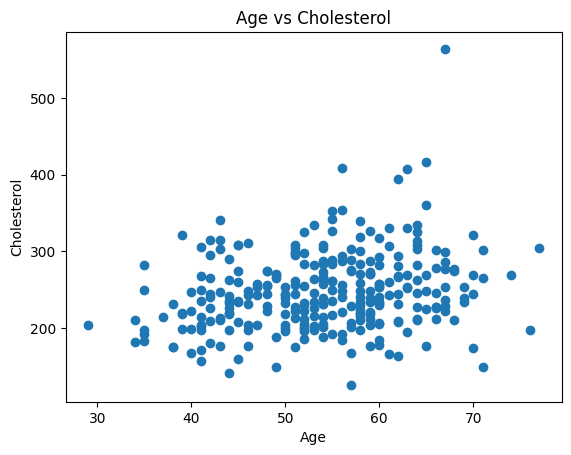

In [5]:
plt.scatter(df['age'], df['chol'])
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.title("Age vs Cholesterol")
plt.show()

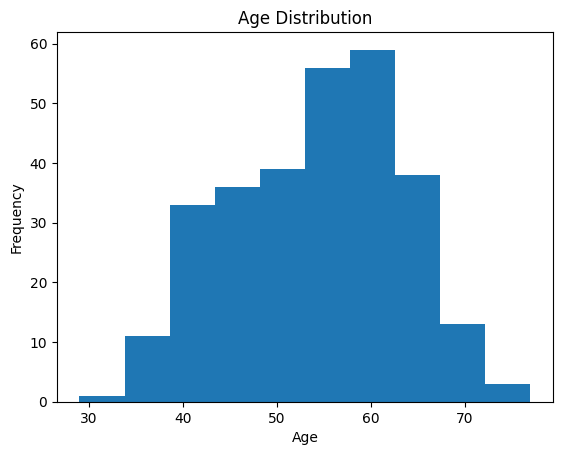

In [6]:
plt.hist(df['age'], bins=10)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

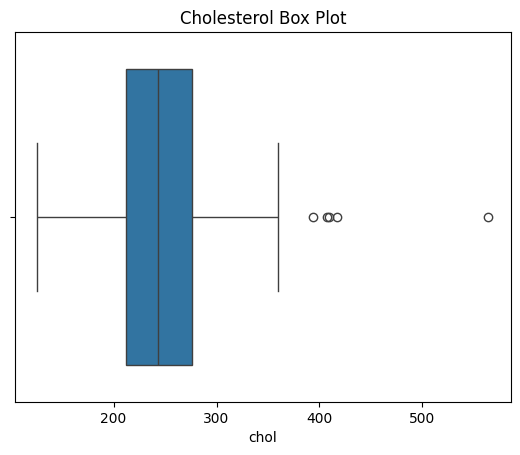

In [7]:
sns.boxplot(x=df['chol'])
plt.title("Cholesterol Box Plot")
plt.show()

In [10]:
df.isnull().sum()
df['chol'] = df['chol'].fillna(df['chol'].mean())

In [11]:
Q1 = df['chol'].quantile(0.25)
Q3 = df['chol'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['chol'] < lower) | (df['chol'] > upper)]
outliers

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
28,65,0,2,140,417,1,0,157,0,0.8,2,1,2,1
85,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
96,62,0,0,140,394,0,0,157,0,1.2,1,0,2,1
220,63,1,0,150,407,0,0,154,0,4.0,1,3,3,0
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3,0


In [12]:
df = df[(df['chol'] >= lower) & (df['chol'] <= upper)]

In [13]:
sample_df = df.sample(frac=0.5)
sample_df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1,0
199,65,1,0,110,248,0,0,158,0,0.6,2,2,1,0
44,39,1,2,140,321,0,0,182,0,0.0,2,0,2,1
67,45,0,1,130,234,0,0,175,0,0.6,1,0,2,1
53,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1


In [14]:
df_reduced = df.drop(columns=['fbs'])
df_reduced.head()

,age,sex,cp,trtbps,chol,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,60,1,3,145,233,0,150,0,2.3,0,0,1,1
1,35,1,2,130,250,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,172,0,1.4,2,0,2,1
3,55,1,1,120,236,1,178,0,0.8,2,0,2,1
4,56,0,0,120,354,1,163,1,0.6,2,0,2,1


In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['chol_scaled'] = scaler.fit_transform(df[['chol']])
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output,chol_scaled
0,60,1,3,145,233,1,0,150,0,2.3,0,0,1,1,0.457265
1,35,1,2,130,250,0,1,187,0,3.5,0,0,2,1,0.529915
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,0.333333
3,55,1,1,120,236,0,1,178,0,0.8,2,0,2,1,0.470085
4,56,0,0,120,354,0,1,163,1,0.6,2,0,2,1,0.974359


In [17]:
df['age_group'] = pd.cut(df['age'], bins=3, labels=["Young","Middle","Old"])
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output,chol_scaled,age_group
0,60,1,3,145,233,1,0,150,0,2.3,0,0,1,1,0.457265,Middle
1,35,1,2,130,250,0,1,187,0,3.5,0,0,2,1,0.529915,Young
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,0.333333,Young
3,55,1,1,120,236,0,1,178,0,0.8,2,0,2,1,0.470085,Middle
4,56,0,0,120,354,0,1,163,1,0.6,2,0,2,1,0.974359,Middle


In [18]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 284 entries, 0 to 288
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   age          284 non-null    int64   
 1   sex          284 non-null    int64   
 2   cp           284 non-null    int64   
 3   trtbps       284 non-null    int64   
 4   chol         284 non-null    int64   
 5   fbs          284 non-null    int64   
 6   restecg      284 non-null    int64   
 7   thalachh     284 non-null    int64   
 8   exng         284 non-null    int64   
 9   oldpeak      284 non-null    float64 
 10  slp          284 non-null    int64   
 11  caa          284 non-null    int64   
 12  thall        284 non-null    int64   
 13  output       284 non-null    int64   
 14  chol_scaled  284 non-null    float64 
 15  age_group    284 non-null    category
dtypes: category(1), float64(2), int64(13)
memory usage: 35.9 KB


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output,chol_scaled
count,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000
mean,53.859155,0.686620,1.024648,131.299296,244.612676,0.144366,0.524648,150.137324,0.320423,0.991901,1.422535,0.704225,2.309859,0.570423,0.506892
std,9.126974,0.464686,1.027583,17.595129,44.583324,0.352081,0.514206,23.085465,0.467463,1.127509,0.615741,1.017783,0.596611,0.495890,0.190527
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,0.000000,0.000000,120.000000,212.000000,0.000000,0.000000,133.750000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.367521
50%,54.000000,1.000000,1.000000,130.000000,242.500000,0.000000,1.000000,154.000000,0.000000,0.600000,1.000000,0.000000,2.000000,1.000000,0.497863
75%,60.000000,1.000000,2.000000,140.000000,274.000000,0.000000,1.000000,168.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000,0.632479
max,77.000000,1.000000,3.000000,200.000000,360.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000,1.000000


In [19]:
print("Minimum:", df['chol'].min())
print("Maximum:", df['chol'].max())
print("Mean:", df['chol'].mean())
print("Median:", df['chol'].median())
print("Mode:", df['chol'].mode())

Minimum: 126
Maximum: 360
Mean: 244.61267605633802
Median: 242.5
Mode: 0    204
1    234
Name: chol, dtype: int64


In [20]:
range_val = df['chol'].max() - df['chol'].min()

print("Range:", range_val)
print("Variance:", df['chol'].var())
print("Standard Deviation:", df['chol'].std())
print("Quartiles:\n", df['chol'].quantile([0.25,0.5,0.75]))

Range: 234
Variance: 1987.6727716120045
Standard Deviation: 44.583323918389084
Quartiles:
 0.25    212.0
0.50    242.5
0.75    274.0
Name: chol, dtype: float64


In [21]:
corr_matrix = df.corr()
corr_matrix

/var/folders/xs/_xb9qh5j20x8dmf2xcbx07z40000gp/T/ipykernel_2691/2355143037.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = df.corr()


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output,chol_scaled
age,1.000000,-0.108756,-0.059911,0.268466,0.200863,0.103117,-0.109184,-0.406024,0.111657,0.193105,-0.164799,0.274707,0.052170,-0.212502,0.200863
sex,-0.108756,1.000000,-0.057768,-0.056772,-0.149492,0.039926,-0.063683,-0.049336,0.138556,0.113838,-0.054269,0.079764,0.224036,-0.279584,-0.149492
cp,-0.059911,-0.057768,1.000000,0.085778,-0.142173,0.126866,0.049002,0.274085,-0.354882,-0.116941,0.084006,-0.118014,-0.191178,0.395312,-0.142173
trtbps,0.268466,-0.056772,0.085778,1.000000,0.174117,0.146438,-0.086545,-0.036586,0.070784,0.200075,-0.136957,0.080139,0.076970,-0.133841,0.174117
chol,0.200863,-0.149492,-0.142173,0.174117,1.000000,0.026086,-0.112872,-0.065509,0.143989,0.024463,0.011003,0.068798,0.091410,-0.165304,1.000000
fbs,0.103117,0.039926,0.126866,0.146438,0.026086,1.000000,-0.068519,0.010160,0.039991,-0.010396,-0.070478,0.119580,0.004976,-0.028078,0.026086
restecg,-0.109184,-0.063683,0.049002,-0.086545,-0.112872,-0.068519,1.000000,0.071899,-0.099124,-0.084676,0.134396,-0.080546,-0.013465,0.180248,-0.112872
thalachh,-0.406024,-0.049336,0.274085,-0.036586,-0.065509,0.010160,0.071899,1.000000,-0.381954,-0.361743,0.388172,-0.214226,-0.113933,0.416933,-0.065509
exng,0.111657,0.138556,-0.354882,0.070784,0.143989,0.039991,-0.099124,-0.381954,1.000000,0.303277,-0.263336,0.125631,0.225561,-0.440663,0.143989
oldpeak,0.193105,0.113838,-0.116941,0.200075,0.024463,-0.010396,-0.084676,-0.361743,0.303277,1.000000,-0.588517,0.171880,0.248530,-0.430308,0.024463


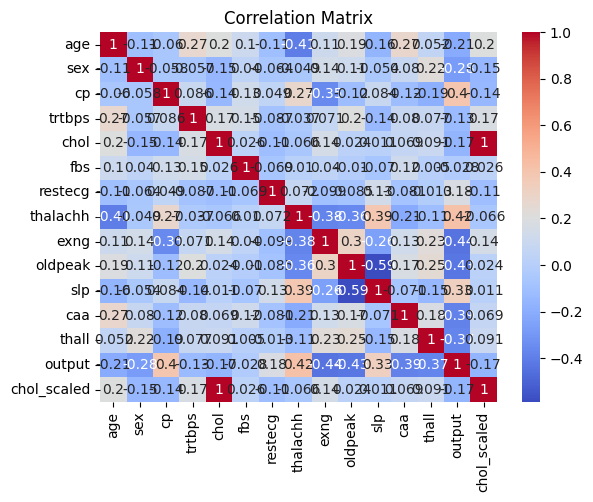

In [22]:
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()